In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd drive/MyDrive/MaliciousCallDetection/

!cp /content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms_backup.zip /content

!unzip /content/spectrograms_backup.zip -d /content


!git config --global user.email "marinescudragos2014@gmail.com"
!git config --global user.name "Marinescu Dragos"


In [ ]:
!pip install -r /content/drive/MyDrive/MaliciousCallDetection/requirements.txt

In [8]:
from tqdm import tqdm
from typing import Optional
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import wandb
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import os
import librosa

In [ ]:
import wandb
wandb.login()

In [ ]:
from collections import Counter
from pathlib import Path

folder = Path("/content/drive/MyDrive/MaliciousCallDetection/dataset/normal")

extensions = Counter(
    p.suffix.lower() or "<no extension>"
    for p in folder.iterdir()
    if p.is_file()
)

extensions

Counter({'.wav': 1648, '.mp3': 40})

In [10]:
import random
def spectrograms_random_splits(spectogram_path,train_ratio=0.8,val_ratio=0.1):

  all_source_files = {} # Structure: { 'original_name': [spectogram_list] }

  for label, category in enumerate(['normal', 'malicious']):
    dir_path = os.path.join(spectogram_path, category)
    if not os.path.exists(dir_path): continue

    for f in os.listdir(dir_path):
      if f.endswith('.pt'):
        source_name=f.split("_spectogram_")[0]
        full_path=os.path.join(dir_path,f)
        if source_name not in all_source_files:
          all_source_files[source_name]={'samples': [], 'label': label}

        all_source_files[source_name]['samples'].append(full_path)

  source_ids = list(all_source_files.keys())
  random.seed(1)
  random.shuffle(source_ids)

  n = len(source_ids)
  train_end = int(n * train_ratio)
  val_end = int(n * (train_ratio + val_ratio))

  train_ids = source_ids[:train_end]
  val_ids = source_ids[train_end:val_end]
  test_ids = source_ids[val_end:]

  def flatten_to_list(ids_list):
    flat_list=[]

    for id in ids_list:
      label=all_source_files[id]['label']
      for sample in all_source_files[id]['samples']:
        flat_list.append((sample,label))
    return flat_list
  return flatten_to_list(train_ids),flatten_to_list(val_ids),flatten_to_list(test_ids)

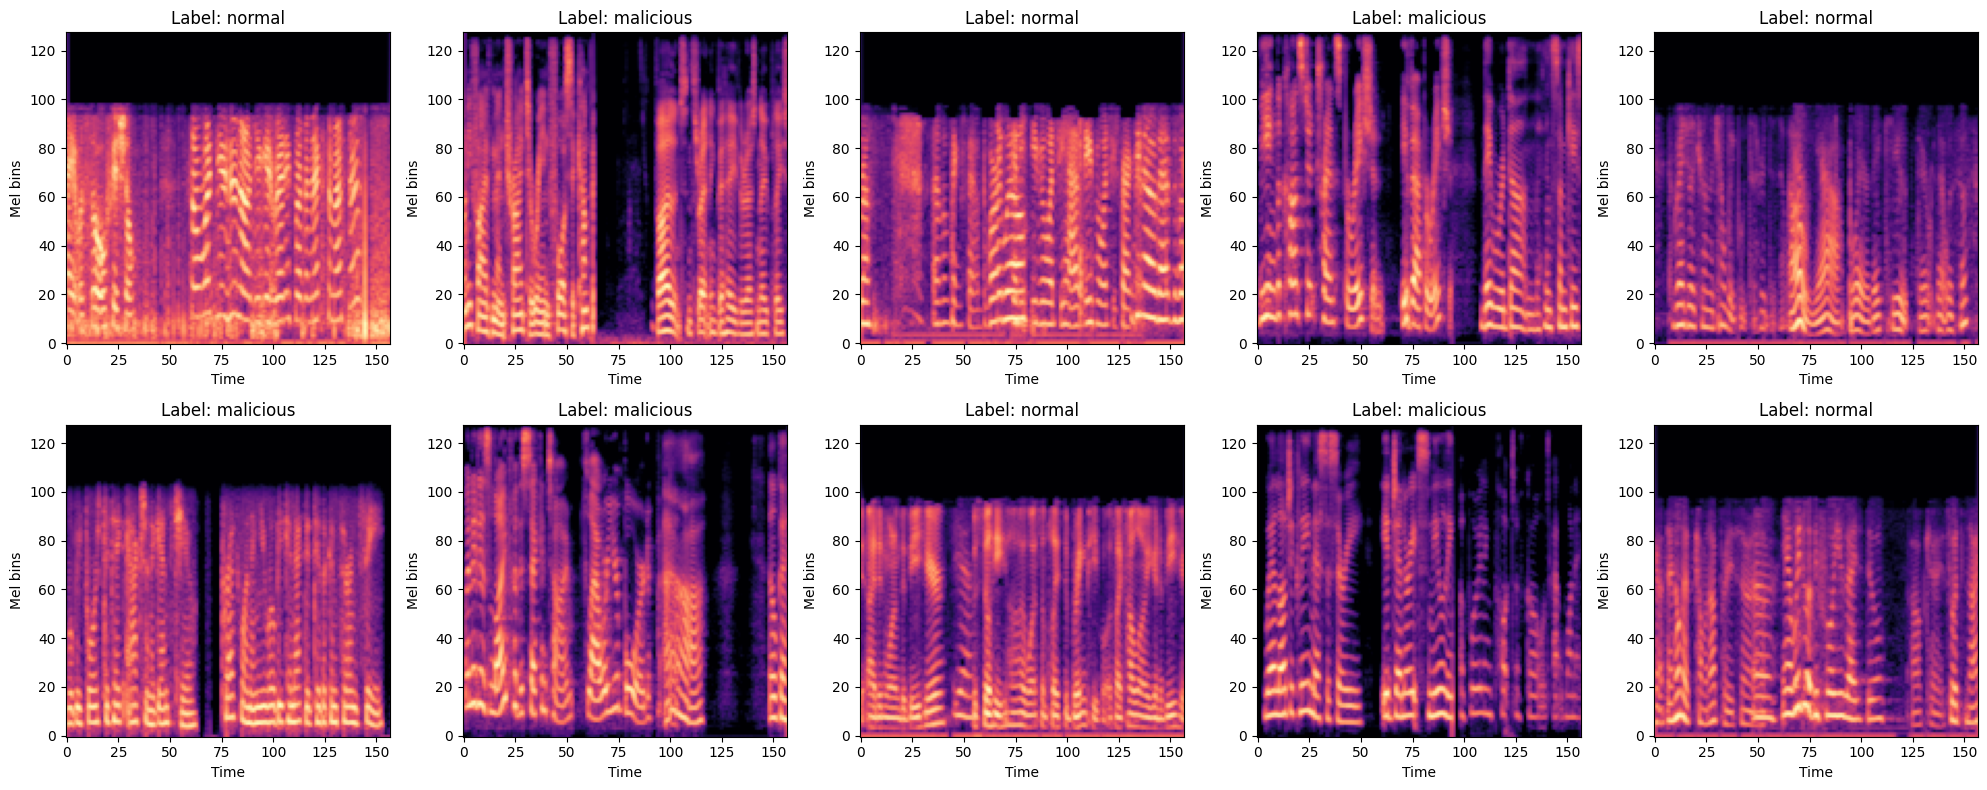

In [11]:
import random
class Spectrogram(Dataset):
  def __init__(self,file_list):
    self.samples=file_list

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    path,label=self.samples[idx]
    mel_tensor=torch.load(path)
    return mel_tensor,label,path

train,test,val=spectrograms_random_splits("/content/spectograms")
specs = train + test + val
p=Spectrogram(specs)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

random_spectrograms=np.random.choice(len(p), size=10, replace=False)
for idx,spectogram_idx in enumerate(random_spectrograms):
    mel, label,_ = p[spectogram_idx]          # mel: (1, 128, 157)
    mel = mel.squeeze(0)       # (128, 157)

    axes[idx].imshow(
        mel,
        origin='lower',
        aspect='auto',
        cmap='magma'
    )

    axes[idx].set_title(f"Label: {'malicious' if label==1 else 'normal'}")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("Mel bins")

plt.tight_layout()
plt.show()

In [12]:

def configure_optimizer(model: nn.Module,lr=0.001) -> optim.Optimizer:
    return optim.Adam(model.parameters(), lr)

class CNN(nn.Module): #Dropout , BatchNorm?
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            #we use padding because we don't want to loose pixels from the images margins, now the output matrix is exactly as the input
            #when working with spectrograms this is important
            #formula : out=(W−K+2P)/S ​+ 1
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),#in_channels=1 because spectogram is grayscale not RGB
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),#reduce image in half, concentrating on the most imp pixel

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2: The "Bulletproof" Funnel
        # This forces the spatial dimensions down to 1x1, regardless of input length.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Block 3: Classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 128), # It's 32 because the last Conv2d output 32 channels
            nn.ReLU(),
            nn.Dropout(0.5), # Added dropout to prevent overfitting
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x



In [ ]:
%cd /content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms/normal
%ls -1 | wc -l
#28014 malicious
#22354 normal

/content/drive/MyDrive/MaliciousCallDetection/dataset/spectograms/normal
22354


In [13]:
#this has been modified with clipping and standardization
def save_spectrograms(base_path, output_path, sr=16000, window_size=5.0, min_overlap=1.5):
    window_size_samples = int(window_size * sr)
    min_overlap_samples = int(min_overlap * sr)

    for category in ['normal', 'malicious']:
        os.makedirs(os.path.join(output_path, category), exist_ok=True)

    print(f"Processing data from '{base_path}'...")

    for label, category in enumerate(['normal', 'malicious']):
        dir_path = os.path.join(base_path, category)
        if not os.path.exists(dir_path):
            continue

        valid_files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.wav', '.mp3'))]

        print(f"\nProcessing category: {category.upper()} ({len(valid_files)} files)")

        for f in tqdm(valid_files, desc=f"{category} progress", unit="file"):
            path = os.path.join(dir_path, f)

            try:
                audio_full, _ = librosa.load(path, sr=sr)
                total_samples = len(audio_full)
            except Exception as e:
                print(f"Error loading {f}: {e}")
                continue

            if total_samples < int(8.5 * sr) and total_samples >= window_size_samples:
                step = max(1, total_samples - window_size_samples)
            else:
                step = window_size_samples - min_overlap_samples

            window_idx = 0
            for start in range(0, total_samples - window_size_samples + 1, step):
                save_file_name = f"{os.path.splitext(f)[0]}_spectogram_{window_idx}.pt"
                save_path = os.path.join(output_path, category, save_file_name)

                if os.path.exists(save_path):
                    window_idx += 1
                    continue

                # in-memory slicing
                audio_segment = audio_full[start : start + window_size_samples]

                mel_spec = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_fft=2048,hop_length=512, n_mels=128) #shape=(128,157)
                log_mel = librosa.power_to_db(mel_spec, ref=np.max) #log_mel=10⋅log10​(mel_spec)
                log_mel = np.clip(log_mel, -80, 0) #avoid outliers
                log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-9)
                tensor_mel = torch.tensor(log_mel).unsqueeze(0) #unsqueeze(0) adds an extra layer at pos 0

                torch.save(tensor_mel, save_path)
                window_idx += 1

    print(f"\nDone! Every spectogram is in '{output_path}'.")
save_spectrograms("/content/drive/MyDrive/MaliciousCallDetection/dataset","/content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms")

Normal data=18462, Malicious=22211
Weights applied: Normal=1.10, Malicious=0.92
Starting training on cuda...


Epoch [1/25] | Loss Train: 0.2359 | Loss Validation: 0.6868 | Accuracy: 73.71%
Validation Loss droped. We saved the current model.


Epoch [2/25] | Loss Train: 0.0943 | Loss Validation: 0.5097 | Accuracy: 81.23%
Validation Loss droped. We saved the current model.


Epoch [3/25] | Loss Train: 0.0666 | Loss Validation: 0.1301 | Accuracy: 96.36%
Validation Loss droped. We saved the current model.


Epoch [4/25] | Loss Train: 0.0542 | Loss Validation: 0.6761 | Accuracy: 78.03%


...

Epoch [21/25] | Loss Train: 0.0247 | Loss Validation: 0.0427 | Accuracy: 98.35%


Epoch [22/25] | Loss Train: 0.0232 | Loss Validation: 0.0400 | Accuracy: 98.47%


Epoch [23/25] | Loss Train: 0.0233 | Loss Validation: 0.0516 | Accuracy: 98.17%


Epoch [24/25] | Loss Train: 0.0229 | Loss Validation: 0.0415 | Accuracy: 98.41%


Epoch [25/25] | Loss Train: 0.0232 | Loss Validation: 0.0396 | Accuracy: 98.47%
Done training. Best model saved as: /content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v4_best.pt
Load the model from: /content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v4_best.pt...
Start testing...

 31 (False Negatives):
 - fraud_call38_spectogram_0.pt
 - fraud_call38_spectogram_1.pt
 - fraud_call38_spectogram_2.pt
 - fraud_call51_spectogram_0.pt
 - fraud_call51_spectogram_1.pt
 - fraud_call17_spectogram_2.pt
 - fraud_call17_spectogram_1.pt
 - fraud_call17_spectogram_0.pt
 - 727866_normalized_spectogram_1.pt
 - fraud_call164_spectogram_2.pt

        FINAL RESULTS
Accuracy: 99.03%
Precision: 0.9945 How many relevant samples did we get
Sensibilitate (Recall): 0.9887 How many malicious did we get right
F1-Score: 0.9916 Final Grade


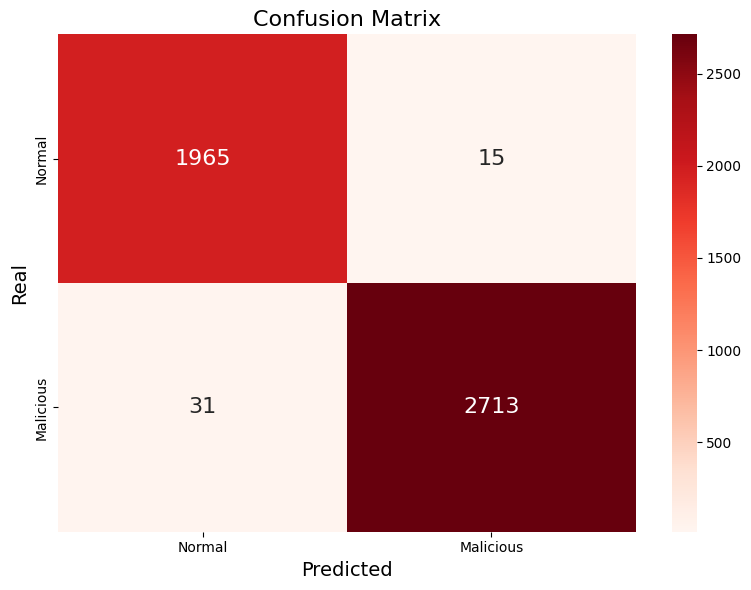

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,███████▄▄▄▄▄▄▄▄▄▂▂▂▂▁▁▁▁▁
train/accuracy,▁▆▇▇▇████████████████████
train/loss,█▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▇▂██▆████▇▇█▆██████████
val/loss,█▆▂█▁▁▃▁▂▁▁▂▂▁▃▁▁▁▁▁▁▁▁▁▁
epoch,25
lr,2e-05
test/accuracy,99.02625
test/f1,0.99159
test/precision,0.9945


In [17]:
def main(model_version: int,
         lr: float=3e-4,
         epochs: int=25,
         batch_size: int=32):
  data_path='/content/spectograms'


  train_model(
        path=data_path,
        model_no=model_version,
        lr=lr,
        epochs=epochs,
        bs=batch_size
    )

if __name__ == "__main__":
  main(model_version=4)


In [13]:
def evaluate_best_model(model_path: str,
                        test_loader: torch.utils.data.DataLoader,
                        device: torch.device,
                        run: Optional[wandb.sdk.wandb_run.Run]):

  if not os.path.exists(model_path):
    print(f"ERORRE: Nu am găsit niciun model la calea: {model_path}")
    return

  print(f"Load the model from: {model_path}...")

  misclassified_malicious=[]

  model = CNN().to(device)
  model.load_state_dict(torch.load(model_path, map_location=device))

  model.eval()

  all_preds = []
  all_labels = []

  print("Start testing...")

  with torch.no_grad():
    for X_test, y_test,paths in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      pred = model(X_test)
      predicted=pred.argmax(dim=1)

      for i in range(len(y_test)):
        if y_test[i] == 1 and predicted[i] == 0:
          file_name = os.path.basename(paths[i])
          misclassified_malicious.append(file_name)

      # GPU->CPU for Scikit-Learn
      all_preds.extend(predicted.cpu().numpy())
      all_labels.extend(y_test.cpu().numpy())

  accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
  precision = precision_score(all_labels, all_preds, zero_division=0) #How many relevant samples did we get  tp/(tp+fp)
  recall = recall_score(all_labels, all_preds, zero_division=0) #How many malicious did we get right tp/(tp+fn)
  f1 = f1_score(all_labels, all_preds, zero_division=0) #Final grade  2*p*r/(p+r)
  if run:
    run.summary["test/accuracy"] = accuracy
    run.summary["test/precision"] = precision
    run.summary["test/recall"] = recall
    run.summary["test/f1"] = f1

    run.log({"test/confusion_matrix": wandb.plot.confusion_matrix(
            probs=None,
            y_true=all_labels,
            preds=all_preds,
            class_names=['Normal', 'Malicious']
        )})
    print(f"\n {len(misclassified_malicious)} (False Negatives):")
    for name in misclassified_malicious[:10]:
        print(f" - {name}")

    my_table = wandb.Table(columns=["File Name", "Status"])
    for name in misclassified_malicious:
        my_table.add_data(name, "False Negative")
    run.log({"misclassified_files": my_table})


  print("\n" + "="*40)
  print("        FINAL RESULTS")
  print("="*40)
  print(f"Accuracy: {accuracy:.2f}%")
  print(f"Precision: {precision:.4f} How many relevant samples did we get")
  print(f"Sensibilitate (Recall): {recall:.4f} How many malicious did we get right")
  print(f"F1-Score: {f1:.4f} Final Grade")

  # Confusion Matrix
  cm = confusion_matrix(all_labels, all_preds)

  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
              xticklabels=['Normal', 'Malicious'],
              yticklabels=['Normal', 'Malicious'],
              annot_kws={"size": 16})

  plt.ylabel('Real', fontsize=14)
  plt.xlabel('Predicted', fontsize=14)
  plt.title('Confusion Matrix', fontsize=16)
  plt.tight_layout()
  plt.show()

In [14]:
def train_model(path: str,
                model_no: int,
                lr: float,
                epochs: int,
                bs: int):

  model = CNN()
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = model.to(device)
  if device.type=="cpu" :
    print("ERROR! Not using GPU")
    return

  train_files,val_files,test_files=spectrograms_random_splits(path)

  count_normal=len([f for f in train_files if f[1]==0])
  count_mal=len([f for f in train_files if f[1]==1])

  total_train = count_normal + count_mal
  w_normal = total_train / (2 * count_normal)
  w_malicious = total_train / (2 * count_mal)

  run=wandb.init(entity="dragosmarinescu19-babes-bolyai-university",
              name=f"run{model_no}",
              project="MaliciousCallDetection",
              config={
                  "lr":lr,
                  "batch_size":bs,
                  "epochs":epochs,
                  "normal_weights":w_normal,
                  "malicious_weights":w_malicious,
                  "optimizer":"Adam",
                  "model_architecture": "CNN"
               })

  class_weights = torch.tensor([w_normal, w_malicious], dtype=torch.float).to(device)
  print(f"Normal data={count_normal}, Malicious={count_mal}")
  print(f"Weights applied: Normal={w_normal:.2f}, Malicious={w_malicious:.2f}")

  loss_func = nn.CrossEntropyLoss(weight=class_weights)
  optimizer = configure_optimizer(model,run.config.lr)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',  # Monitor loss decrease
    factor=0.5,
    patience=2)

  train_db=Spectrogram(train_files)
  val_db=Spectrogram(val_files)
  test_db=Spectrogram(test_files)

  # before DataLoader train_loader =[1,128,157]
  # after DataLoader train_loader=[32,1,128,157] 32 bathces, 1 channel, height, width
  train_loader = DataLoader(train_db, batch_size=run.config.batch_size, shuffle=True,num_workers=2,pin_memory=True,persistent_workers=True)
  val_loader = DataLoader(val_db, batch_size=run.config.batch_size, shuffle=False,num_workers=2,pin_memory=True,persistent_workers=True)
  test_loader = DataLoader(test_db, batch_size=run.config.batch_size, shuffle=False,num_workers=2,pin_memory=True)

  epochs = run.config.epochs

  best_val_loss = float('inf') # We look after the best score
  best_model_path = f'/content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v{model_no}_best.pt'

  print(f"Starting training on {device}...")

  for epoch in range(epochs):
    model.train() # Put model in training mode
    train_loss = 0.0
    train_correct=0
    train_total=0

    batch_loop=tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

    for X_train, y_train,_ in batch_loop:
      # Move data to the same device as the model
      X_train = X_train.to(device)
      y_train = y_train.to(device)

      optimizer.zero_grad()

      pred = model(X_train)

      loss = loss_func(pred, y_train)

      loss.backward() #calculate how to fix the error

      optimizer.step() #update the weights

      train_loss += loss.item()*X_train.size(0)

      #compare the prediction vector to the y_train vector wich contains labels, then we'll have a boolean tensor
      #after the sum we'll have the number of True elements inside a scalar tensor
      #then we use item() to get the number as a python int
      train_correct+=(pred.argmax(dim=1)==y_train).sum().item()
      train_total+=y_train.size(0)

      current_acc=100 * train_correct / train_total
      batch_loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.2f}%")

    train_acc=train_correct/train_total
    avg_train_loss=train_loss/len(train_loader.dataset)

    # VALIDATION

    model.eval() # STOP the dropout
    val_loss = 0.0
    val_correct=0
    val_total=0

    with torch.no_grad():
      for X_val, y_val,_ in val_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)

        pred = model(X_val)
        loss = loss_func(pred, y_val)
        val_loss += loss.item() * X_val.size(0)

        # Accuracy
        val_correct += (pred.argmax(dim=1) == y_val).sum().item()
        val_total+=y_val.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    val_acc = val_correct/val_total
    run.log({"train/loss":avg_train_loss,
             "train/accuracy":train_acc,
             "val/loss":avg_val_loss,
             "val/accuracy":val_acc,
             "lr":current_lr,
             "epoch":epoch+1
             })

    print(f"Epoch [{epoch+1}/{epochs}] | Loss Train: {avg_train_loss:.4f} | Loss Validation: {avg_val_loss:.4f} | Accuracy: {val_acc*100:.2f}%")

    #SAVE
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save(model.state_dict(), best_model_path)
      print(f"Validation Loss droped. We saved the current model.")

  print(f"Done training. Best model saved as: {best_model_path}")

  evaluate_best_model(best_model_path, test_loader, device,run)

  run.finish()
# train_model(path="/content/spectrograms/spectrograms",model_no=2,lr=3e-4,epochs=10,bs=32)

In [24]:
def predict_audio(model_path,file_path,device,sr=16000, n_mels=128,window_size=5.0,min_overlap=1.5):
  model = CNN()
  model.load_state_dict(torch.load(model_path, map_location=device))
  model.to(device)
  model.eval()


  window_size_samples = int(window_size * sr)
  min_overlap_samples = int(min_overlap * sr)

  try:
    audio, _ = librosa.load(file_path, sr=sr)
    total_samples=len(audio)
    if(total_samples<2.5*sr):
      print("Audio too short for a reliable prediction")
      return
  except Exception as e:
    print(f"Error loading {file_path}: {e}")

  if total_samples<window_size_samples:
    padding_needed = window_size_samples - total_samples
    audio = np.pad(audio, (0, padding_needed), mode='constant')
    total_samples=len(audio)
    step=1
  else:
    if total_samples < int(8.5 * sr) and total_samples >= window_size_samples:
      step = max(1, total_samples - window_size_samples)
    else:
      step = window_size_samples - min_overlap_samples

  spectrograms=[]
  for start in range(0, total_samples - window_size_samples + 1, step):
    audio_segment = audio[start : start + window_size_samples]
    mel_spec = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_mels=128)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max) #shape=(128,157)
    tensor_mel = torch.tensor(log_mel).unsqueeze(0).unsqueeze(0) # shape: [1, 1, n_mels, time]
    spectrograms.append(tensor_mel)

  fig, axes = plt.subplots(1, len(spectrograms), figsize=(12,4),squeeze=False)

  for idx, tensor in enumerate(spectrograms):

      mel = tensor.squeeze(0).squeeze(0).cpu().numpy()   # (128,157)

      ax = axes[0, idx]
      im = ax.imshow(mel, origin='lower', aspect='auto', cmap='magma')
      ax.set_title(f"Spectrogram {idx}")
      ax.set_xlabel("Time")
      ax.set_ylabel("Mel bins")

  plt.tight_layout()
  plt.show()
  with torch.no_grad():
    predicted=0
    total_probs=[]
    for x in spectrograms:
      x=x.to(device)
      pred = model(x)
      prob=torch.softmax(pred,dim=1) #tensor([[0.31, 0.69]])
      total_probs.append(prob.cpu().numpy()[0]) # array([0.31, 0.69], dtype=float32)
      predicted += pred.argmax(dim=1).item()  # 0 = normal, 1 = malicious

  if predicted>=len(spectrograms)/2:
    predicted_class=1
  else: predicted_class=0

  avg_probs=np.mean(total_probs,axis=0)
  confidence=avg_probs[predicted_class]*100

  print("Predicted class: Malicious") if predicted_class==1 else print("Predicted class: Normal")
  print(f"Confidence: {confidence:.2f}")


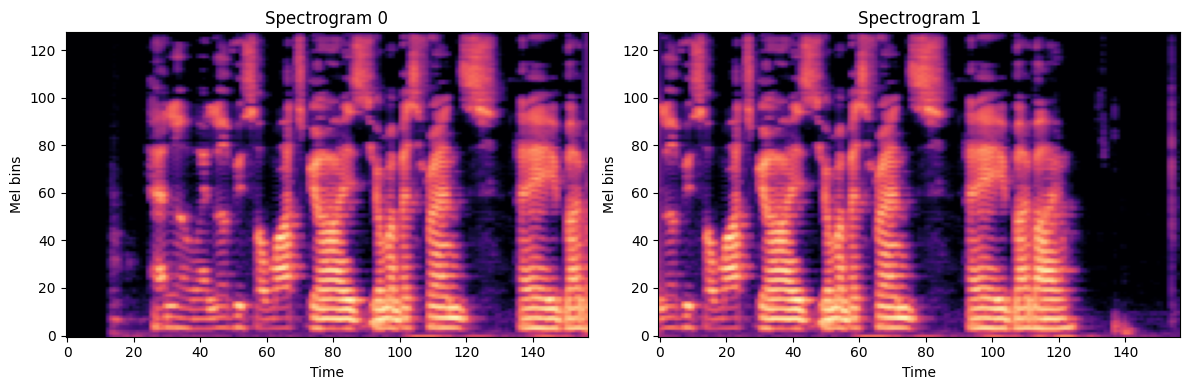

Predicted class: Normal
Confidence: 99.06


In [26]:
#import sounddevice as sd for audio recording
from scipy.io.wavfile import write
import os
import librosa
import torch
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path="/content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v4_best.pt"
file_path = "/content/drive/MyDrive/MaliciousCallDetection/records/normal_1.wav"

predict_audio(model_path,file_path,device)



In [ ]:
!apt-get update
!apt-get install -y libportaudio2 portaudio19-dev

In [ ]:
!git add requirements.txt
!git commit -m 'runned first model. Worked good. I need to randomize the audio files now and not the spectrograms.'